Name: Rahul Gupta

Register No: 2547242

Class: 4 MCA B

---

### Question 1

Import libraries

In [52]:
import pandas as pd
import numpy as np
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt

Load the given road accident dataset

In [2]:
df = pd.read_csv("QP_Data_road_accident_dataset_with_missing.csv")

Display the first 10 rows

In [4]:
print("Dataset first 10 rows:")
df.head(10)

Dataset first 10 rows:


,Country,Year,Month,Day of Week,Time of Day,Urban/Rural,Road Type,Weather Conditions,Visibility Level,Number of Vehicles Involved,...,Number of Fatalities,Emergency Response Time,Traffic Volume,Road Condition,Accident Cause,Insurance Claims,Medical Cost,Economic Loss,Region,Population Density
0,USA,2002,October,Tuesday,Evening,Rural,Street,Windy,NaN,1,...,2,58.625720,7412.752760,Wet,Weather,4,40499.856980,22072.878500,Europe,3866.273014
1,UK,2014,December,Saturday,Evening,Urban,Street,Windy,168.311358,3,...,1,58.041380,4458.628820,Snow-covered,Mechanical Failure,3,6486.600073,9534.399441,North America,2333.916224
2,USA,2012,July,Sunday,Afternoon,Urban,Highway,Snowy,341.286506,4,...,4,NaN,9856.915064,Wet,Speeding,4,29164.412980,58009.145120,South America,4408.889129
3,UK,2017,May,Saturday,Evening,Urban,Main Road,Clear,489.384536,2,...,3,48.554014,4958.646267,Icy,Distracted Driving,3,25797.212570,20907.151300,Australia,2810.822423
4,Canada,2002,July,Tuesday,Afternoon,Rural,Highway,Rainy,348.344850,1,...,4,18.318250,3843.191463,Icy,Distracted Driving,8,15605.293920,13584.060760,South America,3883.645634
5,India,2010,May,Monday,Evening,Urban,Street,Snowy,479.216834,2,...,4,8.205994,360.951795,Dry,Speeding,7,NaN,45995.605250,South America,3626.074027
6,China,2010,March,Monday,Afternoon,Rural,Street,Foggy,386.176217,3,...,3,17.851663,7607.804705,Wet,Weather,9,NaN,52342.431810,Asia,3408.182341
7,USA,2016,July,Friday,Afternoon,Rural,Main Road,Foggy,75.608688,3,...,2,46.740367,6061.407002,Dry,Speeding,8,4262.755621,70652.223520,South America,408.296453
8,Japan,2014,August,Thursday,Afternoon,Rural,Highway,Rainy,387.828675,3,...,2,NaN,3793.850542,Snow-covered,Mechanical Failure,5,37624.775980,13724.630950,Europe,2058.898279
9,USA,2007,April,Monday,Evening,Urban,Highway,Foggy,443.965408,3,...,3,NaN,1140.429308,Snow-covered,Distracted Driving,0,15801.190080,61948.862750,Australia,1840.206143


List all numerical and categorical variables separately

In [21]:
numerical_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_vars = df.select_dtypes(include=['str']).columns.tolist()

print("Numerical variables:", numerical_vars)
print("Categorical variables:", categorical_vars)


Numerical variables: ['Year', 'Visibility Level', 'Number of Vehicles Involved', 'Speed Limit', 'Driver Alcohol Level', 'Driver Fatigue', 'Pedestrians Involved', 'Cyclists Involved', 'Number of Injuries', 'Number of Fatalities', 'Emergency Response Time', 'Traffic Volume', 'Insurance Claims', 'Medical Cost', 'Economic Loss', 'Population Density']
Categorical variables: ['Country', 'Month', 'Day of Week', 'Time of Day', 'Urban/Rural', 'Road Type', 'Weather Conditions', 'Driver Age Group', 'Driver Gender', 'Vehicle Condition', 'Accident Severity', 'Road Condition', 'Accident Cause', 'Region']


Check the data types of all columns and interpret whether any column needs type conversion

In [27]:
print("Data types:")
print(df.dtypes)

Data types:
Country                            str
Year                             int64
Month                              str
Day of Week                        str
Time of Day                        str
Urban/Rural                        str
Road Type                          str
Weather Conditions                 str
Visibility Level               float64
Number of Vehicles Involved      int64
Speed Limit                      int64
Driver Age Group                   str
Driver Gender                      str
Driver Alcohol Level           float64
Driver Fatigue                   int64
Vehicle Condition                  str
Pedestrians Involved             int64
Cyclists Involved                int64
Accident Severity                  str
Number of Injuries               int64
Number of Fatalities             int64
Emergency Response Time        float64
Traffic Volume                 float64
Road Condition                     str
Accident Cause                     str
Insurance Cla

In [54]:
# Type conversion check
# 'Year' is numeric but can be treated as categorical (no mathematical meaning)
# 'Insurance Claims' appears numeric - verify

print("\nUnique values in 'Insurance Claims':", df['Insurance Claims'].unique()[:10])


Unique values in 'Insurance Claims': [4 3 8 7 9 5 0 2 1 6]


---

### Question 2

a. Generate descriptive stats for all numerical variables. Which variable shows the highest variation

In [58]:
# Descriptive statistics for numerical variables
desc_stats = df[numerical_vars].describe()
print(desc_stats)

# Variable with highest variation (standard deviation)
highest_var = desc_stats.loc['std'].idxmax()
print(f"\nVariable with highest variation: {highest_var}")

       Emergency Response Time   Medical Cost  Economic Loss  \
count            118824.000000  106979.000000  118800.000000   
mean                 32.486666   22999.326535   46028.388017   
std                  15.900793   13309.840366   26642.146034   
min                   5.000177     500.110091    1000.335085   
25%                  18.694200   11594.699610   23253.528405   
50%                  32.549514   22687.634120   45484.381415   
75%                  46.288919   33869.677745   67731.981662   
max                  59.999588   49999.930130   99999.622970   

       Driver Alcohol Level  
count         104893.000000  
mean               0.110463  
std                0.066818  
min                0.000002  
25%                0.053893  
50%                0.107667  
75%                0.161436  
max                0.249989  

Variable with highest variation: Economic Loss


b. Compare the mean and median of Medical Cost. What does the difference indicate about Skewness?

In [29]:
medical_cost_mean = df['Medical Cost'].mean()
medical_cost_median = df['Medical Cost'].median()

print(f"Mean of Medical Cost: {medical_cost_mean}")
print(f"Median of Medical Cost: {medical_cost_median}")

# Interpretation
if medical_cost_mean > medical_cost_median:
    print("Skewness: Right-skewed (positive skew)")
else:
    print("Skewness: Left-skewed (negative skew)")

Mean of Medical Cost: 22999.326534801297
Median of Medical Cost: 22687.63412
Skewness: Right-skewed (positive skew)


---

### Question 3

a. Identify all variables containing missing values. Calculate the number and percentage of missing values in each column

In [30]:
# Missing values count and percentage
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
}).sort_values(by='Missing Count', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

                         Missing Count  Missing Percentage
Driver Alcohol Level             27107           20.535606
Medical Cost                     25021           18.955303
Economic Loss                    13200           10.000000
Emergency Response Time          13176            9.981818
Population Density                6600            5.000000
Visibility Level                  6600            5.000000
Traffic Volume                    6600            5.000000


b. Explain and identify which missing value technique can be used for variables Visibility Level, Traffic Volume and Population Density

Ans. 

For Visibility Level, Traffic Volume, Population Density:
- Use mean/median imputation if missingness is random (MCAR/MAR).
- Example: df['Visibility Level'].fillna(df['Visibility Level'].mean(), inplace=True)

c. Explain and identify which missing value technique can be used for variables Driver Alcohol Level, Emergency Response Time and Medical Cost

Ans. 

For Driver Alcohol Level, Emergency Response Time, Medical Cost:
- Driver Alcohol Level: If missing due to non-reporting (MNAR), consider mode imputation or flag missingness.
- Emergency Response Time / Medical Cost: Use median imputation (robust to outliers).
- Example: df['Medical Cost'].fillna(df['Medical Cost'].median(), inplace=True)

d. How can missingness in Driver Alcohol Level be both MAR and MNAR? Explain with reference to the dataset

Ans.

MAR (Missing At Random): Missingness may depend on observed data (e.g., accidents with no alcohol test due to minor severity).

MNAR (Missing Not At Random): Missingness may depend on unobserved data (e.g., drivers hide alcohol consumption).

In this dataset, missingness could be both:
- MAR: If missingness correlates with other variables (e.g., Accident Severity).
- MNAR: If drivers with high alcohol levels are less likely to report.

---

### Question 4

a. Plot a chart showing accidents by Weather Condition, Road Type and Accident Severity

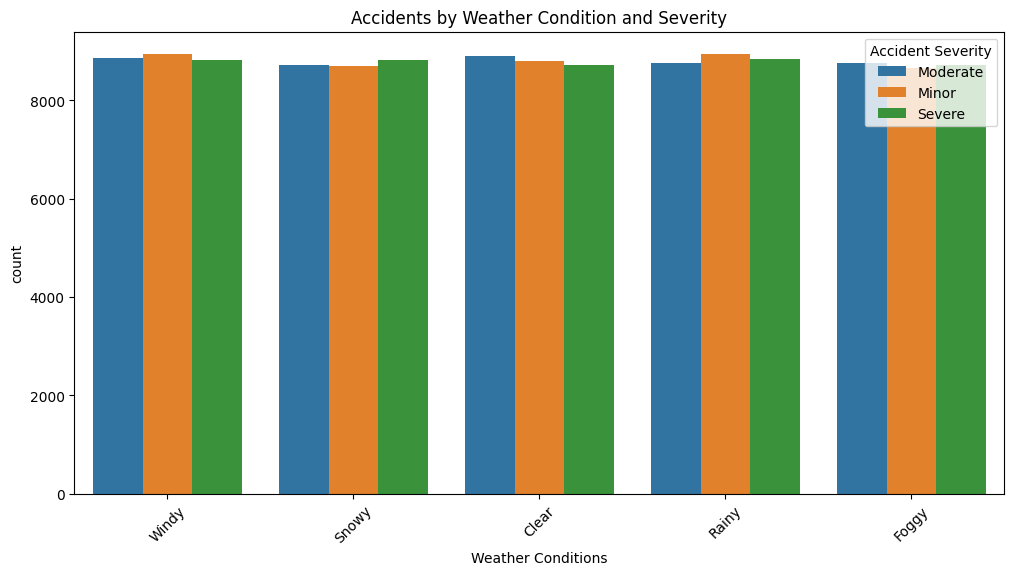

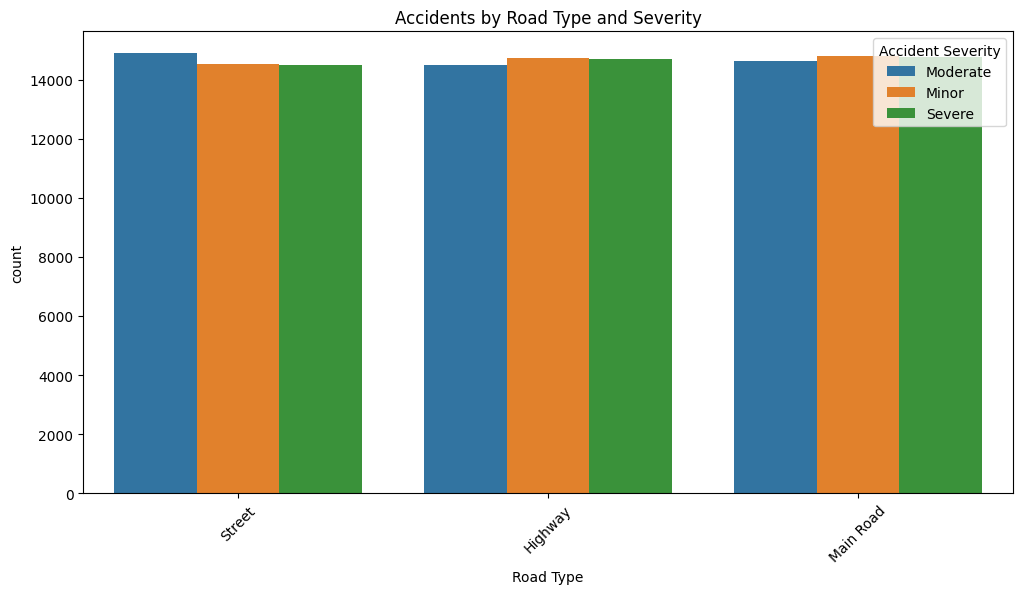

In [51]:
# Grouped bar plot
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Weather Conditions', hue='Accident Severity')
plt.title("Accidents by Weather Condition and Severity")
plt.xticks(rotation=45)
plt.show()

# Stacked bar plot for Road Type and Severity
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Road Type', hue='Accident Severity')
plt.title("Accidents by Road Type and Severity")
plt.xticks(rotation=45)
plt.show()

b. Plot a boxplot for Economic Loss, Medical Cost grouped by Accident Severity

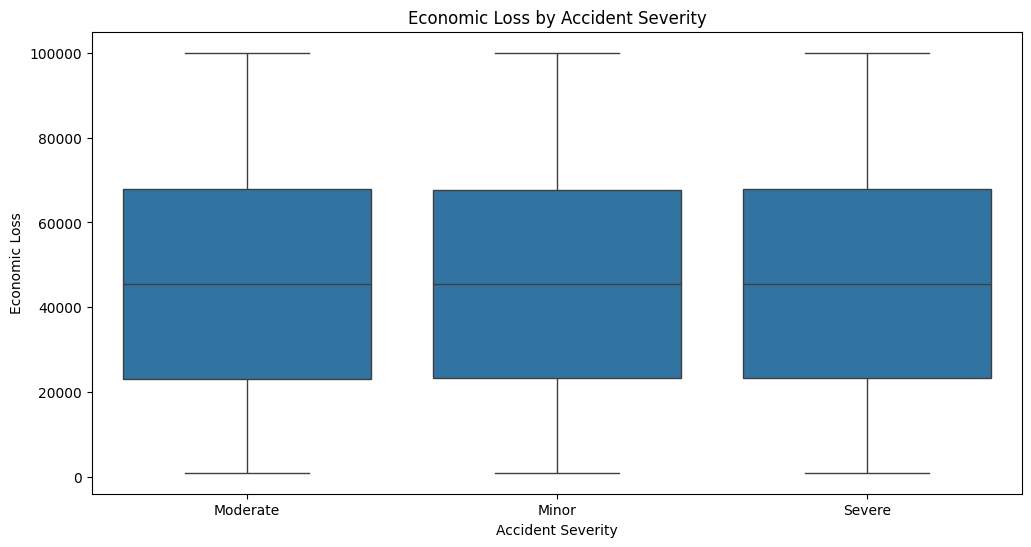

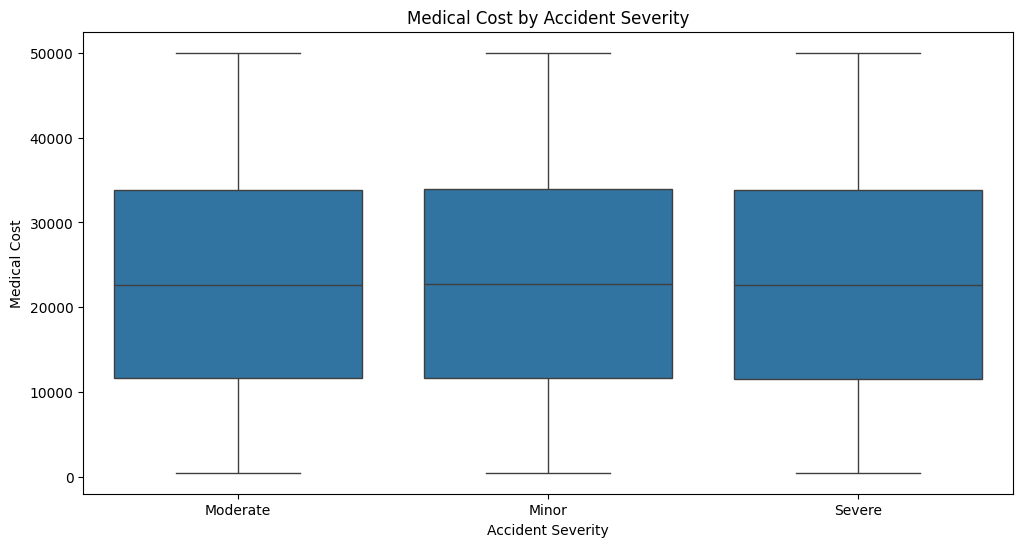

In [33]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Accident Severity', y='Economic Loss')
plt.title("Economic Loss by Accident Severity")
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Accident Severity', y='Medical Cost')
plt.title("Medical Cost by Accident Severity")
plt.show()

c. Plot a scatter plot between Traffic Volume and Accident Severity / Economic Loss

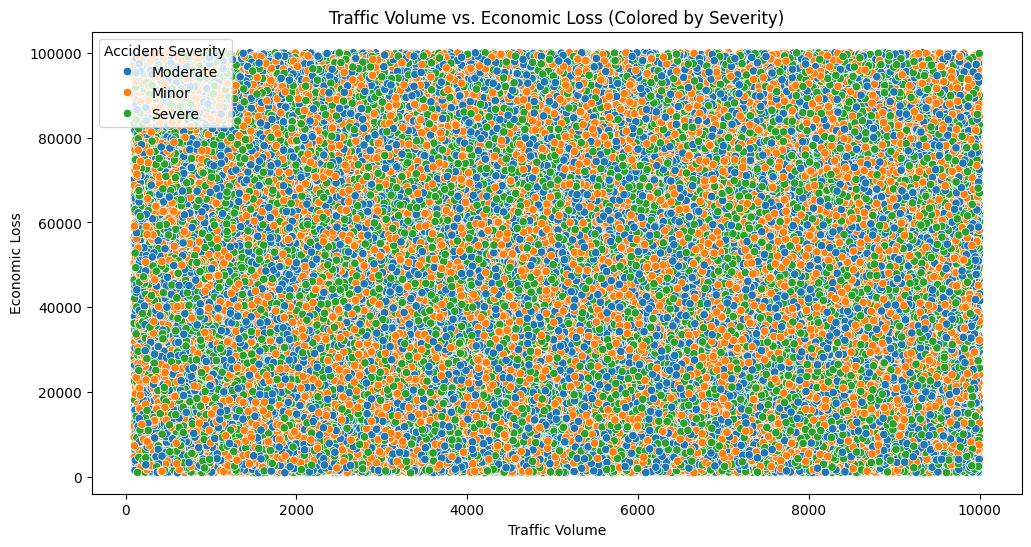

In [ ]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='Traffic Volume', y='Economic Loss', hue='Accident Severity')
plt.title("Traffic Volume vs. Economic Loss (Colored by Severity)")
plt.show()

d. Interpret any 3 charts and explain what they reveal about accident patterns

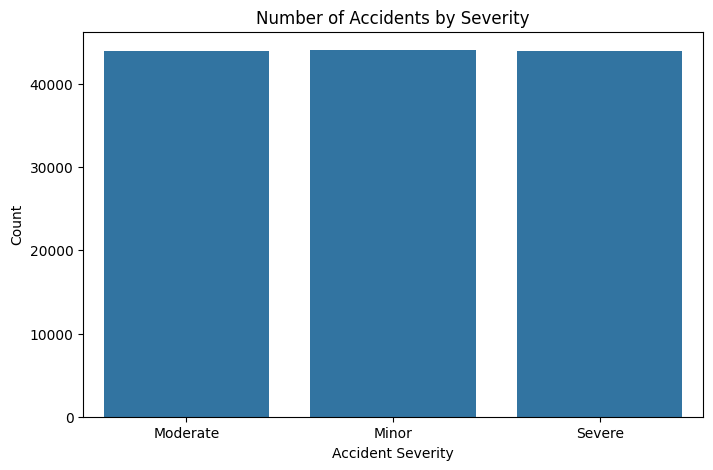

In [84]:
# Bar Chart: Number of Accidents by Accident_Severity

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Accident Severity')
plt.title("Number of Accidents by Severity")
plt.xlabel("Accident Severity")
plt.ylabel("Count")
plt.show()

Accident Pattern: Pattern: This chart shows the frequency of accidents for each severity level - Moderate, Minor, Sever

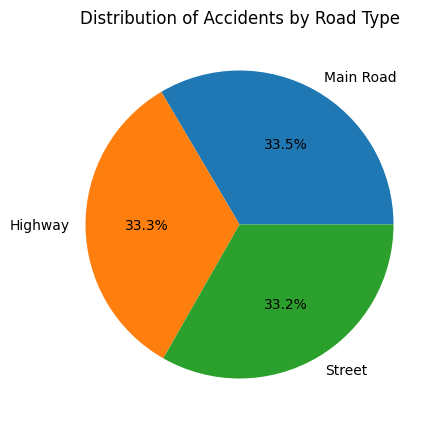

In [45]:
# Pie Chart: Distribution of Accidents by Road_Type

plt.figure(figsize=(8, 5))
df['Road Type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Distribution of Accidents by Road Type")
plt.ylabel("")
plt.show()

Accident Pattern: This chart shows the proportion of accidents across different road types - Main Road, Highway, Street

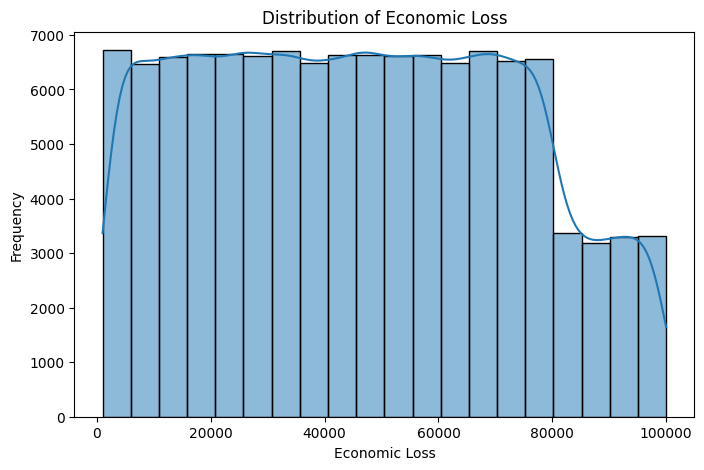

In [49]:
# Histogram: Distribution of Economic_Loss

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Economic Loss', kde=True, bins=20)
plt.title("Distribution of Economic Loss")
plt.xlabel("Economic Loss")
plt.ylabel("Frequency")
plt.show()

Accident Pattern: This chart shows how economic loss is distributed across accidents

---

### Question 5

Perform a correlation analysis on the numerical variables by
creating a correlation matrix. 

Identify the strength and direction of the correlations, and interpret the relationships between Emergency Response Time, Medical Cost,Economic Loss, Driver Alcohol Level, and Accident Severity. 

Further, explain why categorical variables should not be directly included in correlation analysis without appropriate encoding.

In [62]:
# Convert Accident Severity to Severity_Num

df['Severity_Num'] = df['Accident Severity'].map({'Minor': 1, 'Moderate': 2, 'Severe': 3})

                         Emergency Response Time  Medical Cost  Economic Loss  \
Emergency Response Time                 1.000000      0.000265      -0.000455   
Medical Cost                            0.000265      1.000000       0.005073   
Economic Loss                          -0.000455      0.005073       1.000000   
Driver Alcohol Level                    0.000784     -0.001417      -0.002992   
Severity_Num                           -0.000578     -0.002917       0.000517   
Traffic Volume                         -0.001719     -0.003406       0.002142   

                         Driver Alcohol Level  Severity_Num  Traffic Volume  
Emergency Response Time              0.000784     -0.000578       -0.001719  
Medical Cost                        -0.001417     -0.002917       -0.003406  
Economic Loss                       -0.002992      0.000517        0.002142  
Driver Alcohol Level                 1.000000      0.000052        0.004581  
Severity_Num                         0.000

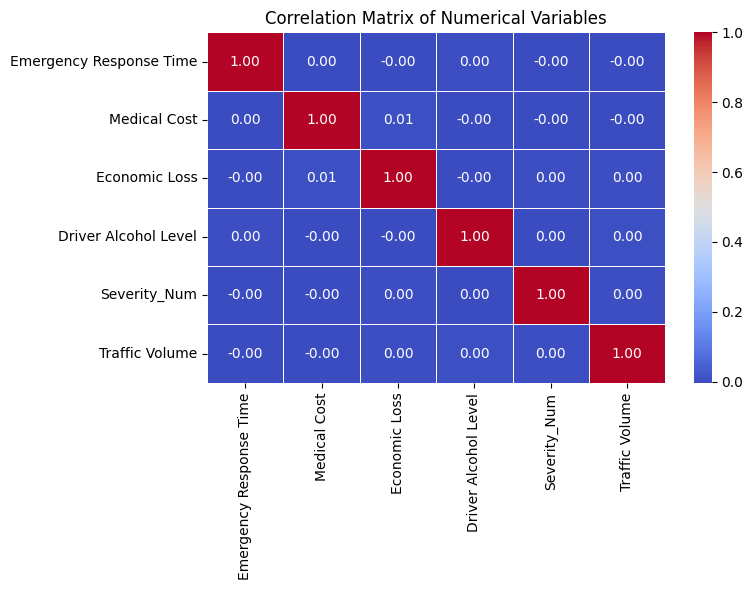

In [63]:
# Select key numerical columns
corr_cols = ['Emergency Response Time', 'Medical Cost', 'Economic Loss',
             'Driver Alcohol Level', 'Severity_Num', 'Traffic Volume']

corr_matrix = df[corr_cols].corr()
print(corr_matrix)

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

Interpretation:

- Medical Cost & Economic Loss: likely positive correlation (more cost = more loss)

- Driver Alcohol Level & Severity: positive (higher alcohol → more severe accidents)

- Emergency Response Time & Severity: may be positive (severe accidents take longer)

- Categorical variables (Weather, Road Type etc.) cannot be directly correlated   without encoding (Label/One-Hot) as correlation requires numeric values.

---

### Question 6

a. Use the IQR method to identify outliers for Medical Cost, Economic Loss, Traffic Volume and Emergency Response Time

In [64]:
# a. IQR Outlier Detection
def detect_outliers_iqr(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}, "
          f"Lower={lower:.2f}, Upper={upper:.2f}, Outliers={len(outliers)}")
    return outliers

for col in ['Medical Cost', 'Economic Loss', 'Traffic Volume', 'Emergency Response Time']:
    detect_outliers_iqr(col)

Medical Cost: Q1=11594.70, Q3=33869.68, IQR=22274.98, Lower=-21817.77, Upper=67282.14, Outliers=0
Economic Loss: Q1=23253.53, Q3=67731.98, IQR=44478.45, Lower=-43464.15, Upper=134449.66, Outliers=0
Traffic Volume: Q1=2554.84, Q3=7523.93, IQR=4969.09, Lower=-4898.81, Upper=14977.57, Outliers=0
Emergency Response Time: Q1=18.69, Q3=46.29, IQR=27.59, Lower=-22.70, Upper=87.68, Outliers=0


b. Examine whether high Medical Cost values are errors or meaningful extreme cases

High Medical Cost Interpretation:
- Road accidents can genuinely result in very high medical bills (ICU, surgeries, long recovery)
- These are likely MEANINGFUL EXTREME CASES, not data errors
- Cross-check: if Accident Severity = 'Severe' and Fatalities > 0 → high cost is justified
- Should NOT be removed; consider robust models or log-transformation instead

In [65]:
# Verify: check medical cost for severe accidents
print(df.groupby('Accident Severity')['Medical Cost'].describe())

                     count          mean           std         min  \
Accident Severity                                                    
Minor              39680.0  23045.180923  13319.387433  500.110091   
Moderate           39644.0  22989.816355  13289.106973  501.920576   
Severe             27655.0  22947.166688  13326.086840  501.365848   

                            25%           50%           75%          max  
Accident Severity                                                         
Minor              11627.283537  22797.664165  33959.671985  49996.85700  
Moderate           11612.436848  22680.063880  33808.292763  49998.99995  
Severe             11532.162270  22583.939920  33834.995050  49999.93013  


---

### Question 7

a. How do accident trends and impact metrics vary over time?

Ans.



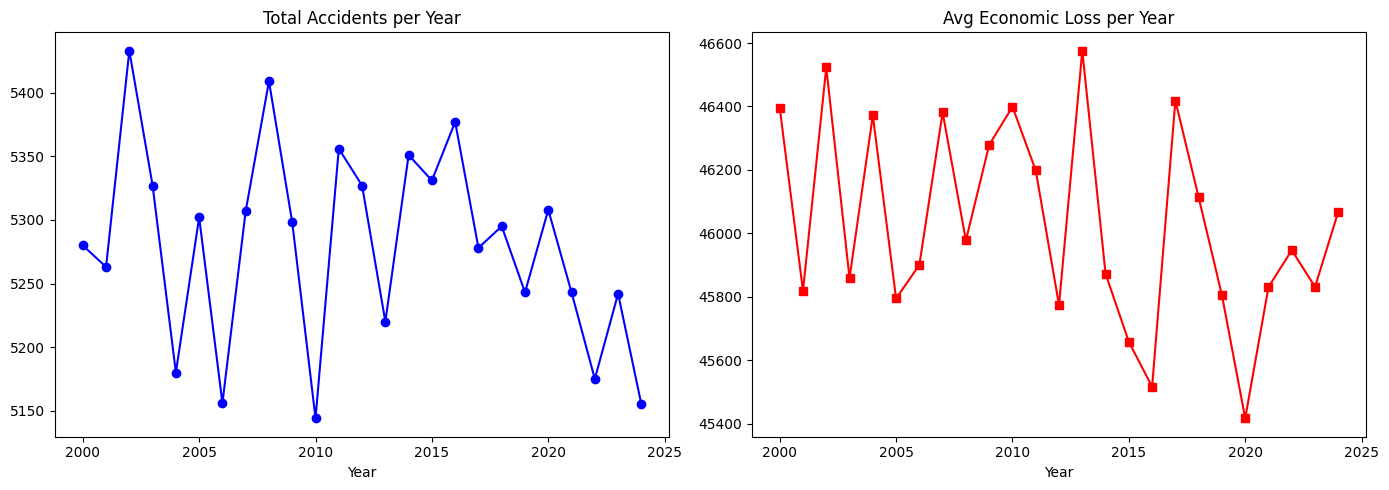

In [66]:
yearly = df.groupby('Year').agg(
    Total_Accidents=('Accident Severity', 'count'),
    Avg_Medical_Cost=('Medical Cost', 'mean'),
    Avg_Economic_Loss=('Economic Loss', 'mean'),
    Avg_Fatalities=('Number of Fatalities', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(yearly['Year'], yearly['Total_Accidents'], marker='o', color='blue')
axes[0].set_title('Total Accidents per Year')
axes[0].set_xlabel('Year')

axes[1].plot(yearly['Year'], yearly['Avg_Economic_Loss'], marker='s', color='red')
axes[1].set_title('Avg Economic Loss per Year')
axes[1].set_xlabel('Year')
plt.tight_layout()
plt.show()

b. How do environmental and road conditions contribute to accident outcomes?

In [70]:
print("\nAvg Fatalities by Weather Condition:")
print(df.groupby('Weather Conditions')['Number of Fatalities'].mean().sort_values(ascending=False))

print("\nAvg Severity encoding by Road Type:")
print(df.groupby('Road Type')['Severity_Num'].mean().sort_values(ascending=False))


Avg Fatalities by Weather Condition:
Weather Conditions
Foggy    2.005165
Rainy    2.003087
Clear    1.995648
Windy    1.987531
Snowy    1.985828
Name: Number of Fatalities, dtype: float64

Avg Severity encoding by Road Type:
Road Type
Street       1.999180
Main Road    1.999072
Highway      1.998839
Name: Severity_Num, dtype: float64


c. What factors most significantly influence accident severity and overall impact?

In [69]:
print("\nCorrelation with Severity:")
factors = ['Driver Alcohol Level', 'Speed Limit', 'Traffic Volume',
           'Emergency Response Time', 'Number of Vehicles Involved']
print(df[factors + ['Severity_Num']].corr()['Severity_Num'].sort_values(ascending=False))


Correlation with Severity:
Severity_Num                   1.000000
Number of Vehicles Involved    0.003024
Traffic Volume                 0.001350
Speed Limit                    0.001313
Driver Alcohol Level           0.000052
Emergency Response Time       -0.000578
Name: Severity_Num, dtype: float64


d. How do accident characteristics and impacts vary geographically?


Accidents and Economic Loss by Region:
               Count  Avg_Economic_Loss  Avg_Fatalities
Region                                                 
Asia           26351       46344.283107        1.990437
South America  26264       46125.529702        1.990900
Europe         26345       46010.872320        2.005846
North America  26415       45874.133514        1.997729
Australia      26625       45789.300014        1.992300


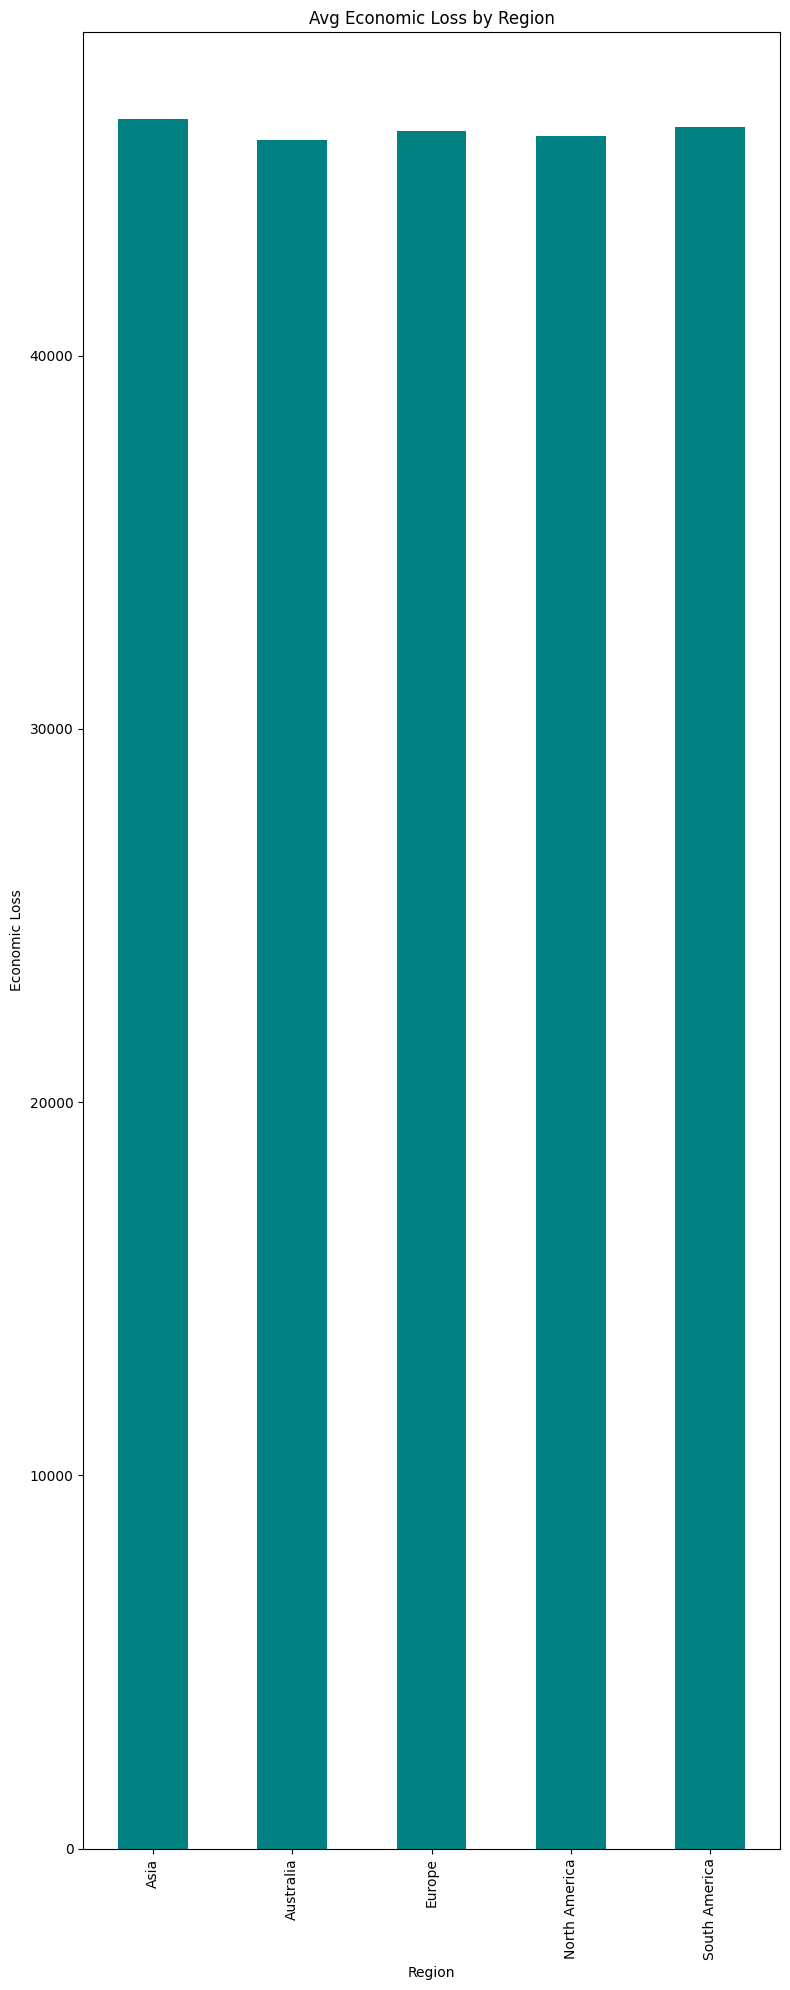

In [80]:
print("\nAccidents and Economic Loss by Region:")
print(df.groupby('Region').agg(
    Count=('Accident Severity', 'count'),
    Avg_Economic_Loss=('Economic Loss', 'mean'),
    Avg_Fatalities=('Number of Fatalities', 'mean')
).sort_values('Avg_Economic_Loss', ascending=False))

# Bar chart for regional comparison
region_data = df.groupby('Region')['Economic Loss'].mean()
region_data.plot(kind='bar', color='teal', figsize=(8, 20))
plt.title('Avg Economic Loss by Region')
plt.ylabel('Economic Loss')
plt.tight_layout()
plt.show()

---